In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from model_utils.plots import plot_results

torch.manual_seed(3407)

In [2]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                           num_layers=num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, target_data, seq_length):
        self.target_data = target_data
        self.seq_length = seq_length
    
    def __len__(self):
        return len(self.target_data) - self.seq_length
    
    def __getitem__(self, idx):
        target_seq = self.target_data[idx:idx+self.seq_length]
        y = self.target_data[idx+self.seq_length]
        
        x = target_seq.reshape(-1, 1)
        
        return torch.FloatTensor(x), torch.FloatTensor([y])

In [ ]:
def lstm_experiment(df, target, train_size=500, val_size=100, forecast_window=161, 
                   seq_length=30, epochs=100, batch_size=32, lr=0.001, dropout=0.0, hidden_size=32, num_layers=1, plot=False):

    total_train_val = train_size + val_size
    train = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].values
    val = df[target][-(val_size+forecast_window):-forecast_window].values
    test = df[target][-forecast_window:].values
    
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.reshape(-1, 1)).flatten()
    val_scaled = scaler.transform(val.reshape(-1, 1)).flatten()

    input_size = 1
    print(f"Training LSTM with hidden_size={hidden_size}, batch_size={batch_size}, num_layers={num_layers}, dropout={dropout}")
    
    # Create Datasets
    train_dataset = TimeSeriesDataset(train_scaled, seq_length)
    # Reduced batch size for more updates per epoch (adjust as needed)
    use_cuda = torch.cuda.is_available()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=use_cuda) 
    
    val_dataset = TimeSeriesDataset(val_scaled, seq_length)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, pin_memory=use_cuda)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Scheduler to reduce LR when validation loss plateaus
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            # Reshape input to (batch_size, seq_len, input_size) if needed by dataset or model
            batch_x = batch_x.view(-1, seq_length, 1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                batch_x = batch_x.view(-1, seq_length, 1) # Ensure shape
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_losses.append(avg_val_loss)
        
        # Step the scheduler
        #scheduler.step(avg_val_loss)
        
        if plot and (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    model.eval()
    forecast = []
    
    current_seq = val_scaled[-seq_length:].tolist()
    
    with torch.no_grad():
        for step in range(forecast_window):
            # Ensure input shape matches (1, seq_length, 1) for single prediction
            x = np.array(current_seq[-seq_length:]).reshape(-1, seq_length, 1) 
            x = torch.FloatTensor(x).to(device)
            
            pred = model(x).cpu().numpy()[0, 0]
            forecast.append(pred)
            
            current_seq.append(pred) # Append new prediction
    
    forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    
    if plot:
        train_index = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].index
        val_index = df[target][-(val_size+forecast_window):-forecast_window].index
        test_index = df[target][-forecast_window:].index

        plot_results(train, val, test, forecast, train_index, val_index, test_index, train_losses, val_losses, target)
    
    return model, scaler, forecast, rmse, mae, test

In [5]:
ITEM_ID = 26008       # Example item_id from sample_head.csv
STORE_ID = 6269        # Example store_id from sample_head.csv
DATA_PATH = '../dataset/data_andre.feather' # Adjust path if needed
TARGET_COL = 'value'
DATE_COL = 'date'

# To converge in fewer epochs (even if each epoch takes longer), we:
# 1. Decrease Batch Size -> More updates per epoch
# 2. Can increase Hidden Size slightly -> More capacity
# 3. Increase learning rate slightly but use scheduler (already added)

EPOCHS = 1000            # Set a bit higher to ensure convergence, though fewer should be needed
BATCH_SIZE = 2         # Smaller batch size for more frequent updates
LEARNING_RATE = 0.001  # Standard LR
HIDDEN_SIZE = 64      # Increased capacity

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Reset index to move 'date' from index to a column
df = df.reset_index()

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)

# Prepare target variable
# Using 'value' as the target (sales at the end of the day)
y = df[TARGET_COL]

print(len(y))


# -----------------------------------------------------------------------------
# DATA SPLITTING
# -----------------------------------------------------------------------------
# Define split sizes
train_size = 500
val_size = 100
forecast_horizon = 161

lookback_window = 30

Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...
761


Training LSTM with train_size=500, val_size=100, forecast_horizon=161, lookback_window=30...
Training LSTM with hidden_size=64, batch_size=2, num_layers=1, dropout=0.0
Epoch [10/1000], Train Loss: 0.007830, Val Loss: 0.002781
Epoch [20/1000], Train Loss: 0.006792, Val Loss: 0.002998
Epoch [30/1000], Train Loss: 0.006519, Val Loss: 0.002646
Epoch [40/1000], Train Loss: 0.006175, Val Loss: 0.003252
Epoch [50/1000], Train Loss: 0.005556, Val Loss: 0.002302
Epoch [60/1000], Train Loss: 0.005020, Val Loss: 0.002483
Epoch [70/1000], Train Loss: 0.004842, Val Loss: 0.002754
Epoch [80/1000], Train Loss: 0.004297, Val Loss: 0.002861
Epoch [90/1000], Train Loss: 0.004619, Val Loss: 0.002493
Epoch [100/1000], Train Loss: 0.003880, Val Loss: 0.002338
Epoch [110/1000], Train Loss: 0.004533, Val Loss: 0.003054
Epoch [120/1000], Train Loss: 0.003352, Val Loss: 0.002388
Epoch [130/1000], Train Loss: 0.004030, Val Loss: 0.002392
Epoch [140/1000], Train Loss: 0.003219, Val Loss: 0.002317
Epoch [150/1000

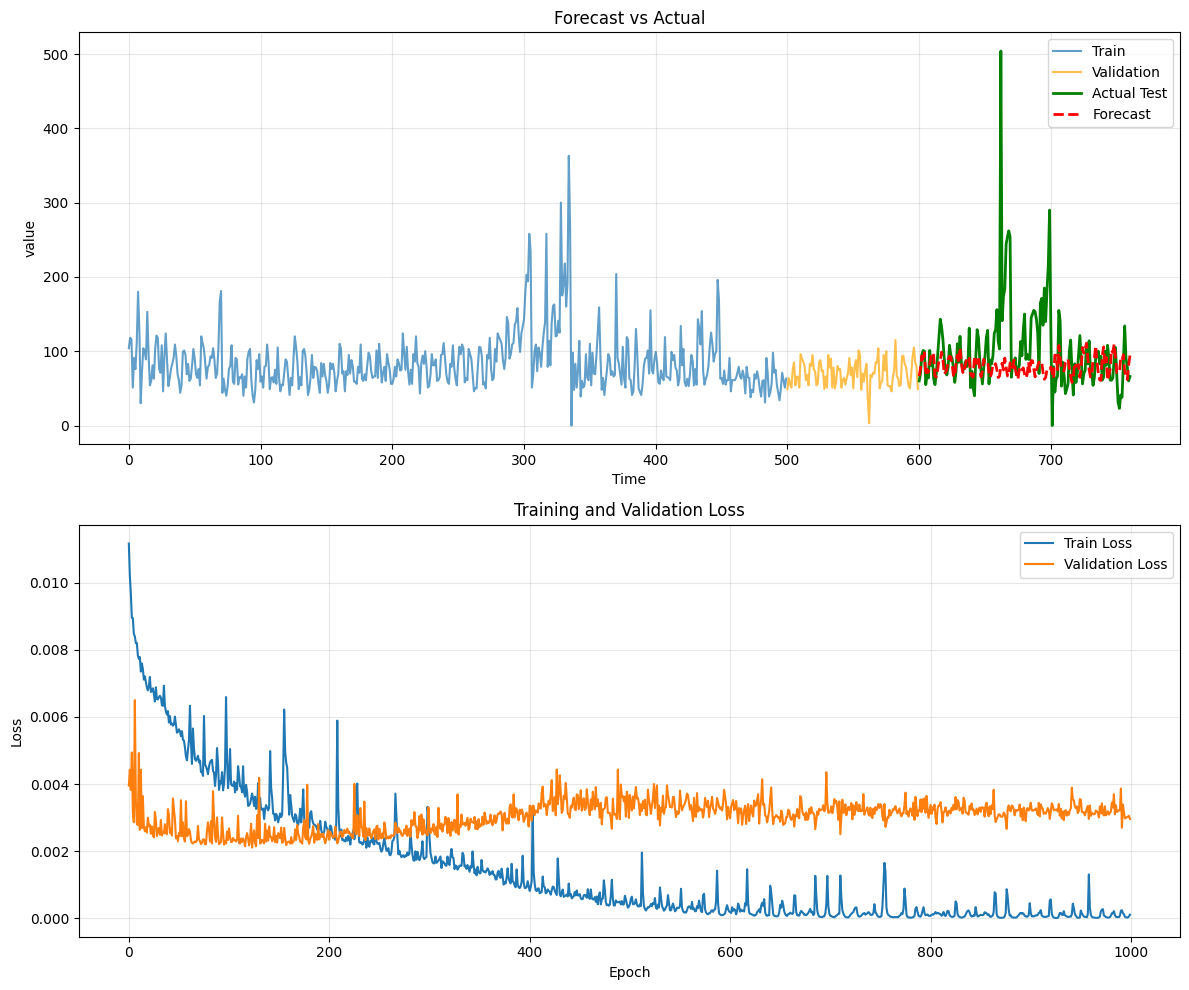

RMSE: 60.3523
MAE: 36.1618


In [7]:
print(f"Training LSTM with train_size={train_size}, val_size={val_size}, forecast_horizon={forecast_horizon}, lookback_window={lookback_window}...")

# Increased model complexity (num_layers=2) to help learn faster per epoch, even if epoch is slower
model, scaler, forecast, rmse, mae, test = lstm_experiment(
    df=df, 
    target=TARGET_COL, 
    train_size=train_size, 
    val_size=val_size,
    forecast_window=forecast_horizon, 
    seq_length=lookback_window,
    hidden_size=HIDDEN_SIZE, 
    num_layers=1,           # Increased number of layers
    dropout=0.0,            # Added dropout for regularization with more layers
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    lr=LEARNING_RATE, 
    plot=True
)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")